# Point Estimation: Bias, Consistency, and Efficiency

## Learning Objectives

By the end of this notebook you will be able to:

1. Define what an **estimator** is and distinguish it from an **estimate**.
2. Evaluate estimators using **bias**, **variance**, and **mean squared error (MSE)**.
3. Explain **consistency** (convergence with more data) and **efficiency** (minimum-variance estimator).
4. Prove that $\bar{X}$ is unbiased for $\mu$ and $S^2$ is unbiased for $\sigma^2$ (Bessel's correction, formally).
5. Understand the **bias-variance tradeoff** through the MSE decomposition.

## Prerequisites

- [Module 02](../02_distributions/01_discrete_distributions.ipynb) — named distributions, $E[X]$, $\text{Var}(X)$
- [Module 03](../03_descriptive_stats/01_summary_statistics.ipynb) — sample mean, sample variance, Bessel's correction

In [ ]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import apply_style

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  ✓ media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)

---

## 1. Estimators and Estimates

In Module 03 we computed summary statistics from data. Now we formalise what we were doing: **estimation**.

> **Definition.** An **estimator** $\hat{\theta}$ is a function of the sample data $X_1, X_2, \dots, X_n$ used to approximate an unknown population parameter $\theta$.

An **estimate** is the specific numerical value the estimator produces from a particular sample.

| Parameter $\theta$             | Common estimator $\hat{\theta}$ | Formula                              |
|--------------------------------|---------------------------------|--------------------------------------|
| Population mean $\mu$          | Sample mean $\bar{X}$           | $\frac{1}{n}\sum X_i$                |
| Population variance $\sigma^2$ | Sample variance $S^2$           | $\frac{1}{n-1}\sum(X_i - \bar{X})^2$ |
| Success probability $p$        | Sample proportion $\hat{p}$     | $\frac{\text{successes}}{n}$         |
| Exponential rate $\lambda$     | $1/\bar{X}$                     | Inverse of sample mean               |

The key question: **how good is an estimator?** We need criteria to compare alternatives.

---

## 2. Bias

An estimator is **unbiased** if, on average across all possible samples, it hits the true value:

> **Definition.** The **bias** of an estimator $\hat{\theta}$ for parameter $\theta$ is:
>
> $$\text{Bias}(\hat{\theta}) = E[\hat{\theta}] - \theta$$
>
> $\hat{\theta}$ is **unbiased** if $\text{Bias}(\hat{\theta}) = 0$, i.e., $E[\hat{\theta}] = \theta$.

### The sample mean is unbiased for $\mu$

$$E[\bar{X}] = E\left[\frac{1}{n}\sum_{i=1}^n X_i\right] = \frac{1}{n}\sum_{i=1}^n E[X_i] = \frac{1}{n} \cdot n\mu = \mu \quad \checkmark$$

### The sample variance with $n-1$ is unbiased for $\sigma^2$ (Bessel's correction proved)

We can show that $E\left[\sum(X_i - \bar{X})^2\right] = (n-1)\sigma^2$, so dividing by $n-1$ gives:

$$E[S^2] = E\left[\frac{1}{n-1}\sum(X_i - \bar{X})^2\right] = \sigma^2 \quad \checkmark$$

If we had divided by $n$ instead, we'd get $E[\hat{\sigma}^2_{\text{biased}}] = \frac{n-1}{n}\sigma^2 < \sigma^2$ — systematically underestimating the variance. This is the formal justification for Bessel's correction from Module 03.

In [ ]:
# Demonstrate Bessel's correction empirically
true_mu, true_var = 5.0, 4.0
n_sample = 10
n_experiments = 50_000

biased_vars = []
unbiased_vars = []
means = []

for _ in range(n_experiments):
    sample = rng.normal(true_mu, np.sqrt(true_var), size=n_sample)
    means.append(sample.mean())
    biased_vars.append(sample.var(ddof=0))  # divide by n
    unbiased_vars.append(sample.var(ddof=1))  # divide by n-1

print(f"True μ = {true_mu},  True σ² = {true_var}")
print(f"\nE[X̄]          = {np.mean(means):.4f}  (unbiased ✓)")
print(
    f"E[S²] (ddof=0) = {np.mean(biased_vars):.4f}  (biased: underestimates by factor {(n_sample - 1) / n_sample:.3f})"
)
print(f"E[S²] (ddof=1) = {np.mean(unbiased_vars):.4f}  (unbiased ✓)")

True μ = 5.0,  True σ² = 4.0

E[X̄]          = 4.9990  (unbiased ✓)
E[S²] (ddof=0) = 3.6051  (biased: underestimates by factor 0.900)
E[S²] (ddof=1) = 4.0057  (unbiased ✓)


---

## 3. Variance of an Estimator and the Sampling Distribution

An unbiased estimator can still be **imprecise** — spread out across experiments. The **variance of the estimator** measures this:

$$\text{Var}(\bar{X}) = \text{Var}\left(\frac{1}{n}\sum X_i\right) = \frac{\sigma^2}{n}$$

The **standard error** is $\text{SE}(\bar{X}) = \sigma / \sqrt{n}$ — it shrinks with more data.

The distribution of the estimator across repeated samples is called the **sampling distribution**. By the CLT (Module 02), $\bar{X}$ is approximately Normal for large $n$:

$$\bar{X} \sim \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right) \quad \text{approximately}$$

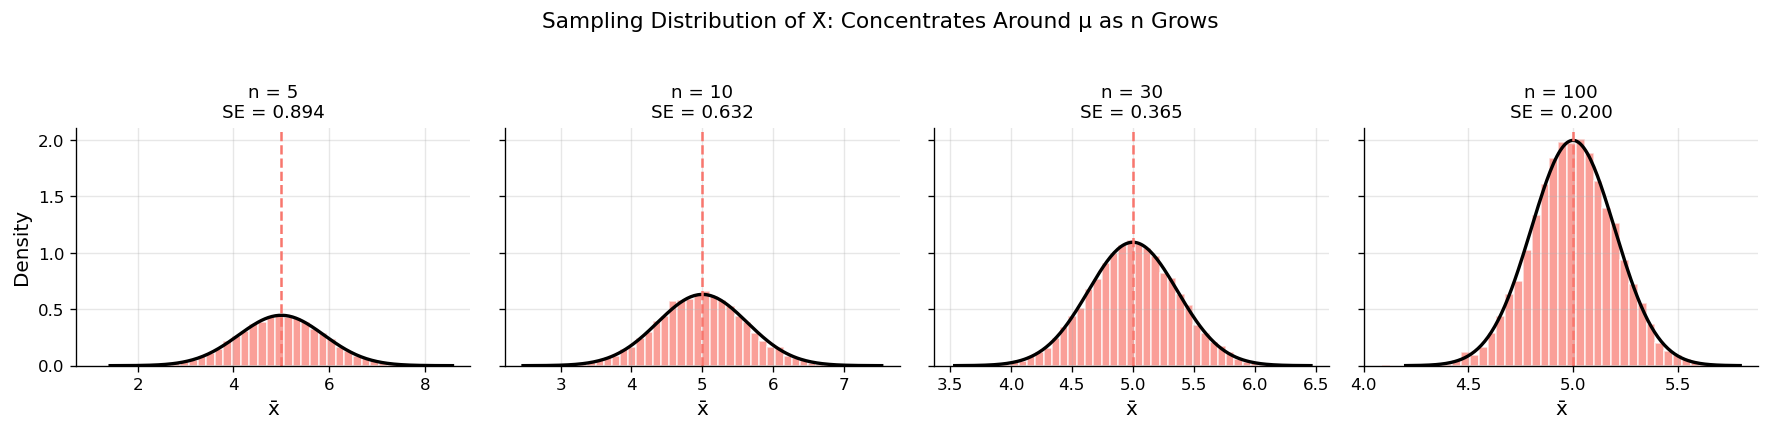

In [ ]:
# Sampling distribution of X̄ for increasing n
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5), sharey=True)
true_mu = 5.0
true_sigma = 2.0

for ax, n in zip(axes, [5, 10, 30, 100]):
    sample_means = [rng.normal(true_mu, true_sigma, n).mean() for _ in range(10_000)]
    ax.hist(sample_means, bins=40, density=True, alpha=0.7, edgecolor="white")

    # Theoretical Normal overlay
    se = true_sigma / np.sqrt(n)
    x = np.linspace(true_mu - 4 * se, true_mu + 4 * se, 200)
    ax.plot(x, stats.norm(true_mu, se).pdf(x), "k-", linewidth=2)

    ax.axvline(true_mu, color="#F8766D", linewidth=1.5, linestyle="--")
    ax.set_title(f"n = {n}\nSE = {se:.3f}", fontsize=11)
    ax.set_xlabel("x̄")

axes[0].set_ylabel("Density")
plt.suptitle(
    "Sampling Distribution of X̄: Concentrates Around μ as n Grows", fontsize=13, y=1.02
)
plt.tight_layout()
plt.show()

As $n$ increases, the sampling distribution of $\bar{X}$ becomes tighter around $\mu$. This is **consistency** — the estimator converges to the true value.

---

## 4. Mean Squared Error and the Bias-Variance Tradeoff

Bias and variance are both undesirable. The **MSE** combines them:

> **Definition.** The **mean squared error** of $\hat{\theta}$ is:
>
> $$\text{MSE}(\hat{\theta}) = E[(\hat{\theta} - \theta)^2]$$

The key decomposition:

$$\boxed{\text{MSE}(\hat{\theta}) = \text{Bias}(\hat{\theta})^2 + \text{Var}(\hat{\theta})}$$

This is the **bias-variance tradeoff**: sometimes a slightly biased estimator with much lower variance can have smaller MSE than an unbiased one.

The following animation illustrates this with a dart-board analogy: bias is how far the centre of the dart cluster is from the bullseye; variance is how spread out the darts are.

In [4]:
from manim import *

cfg.apply_manim_config()
math_text = cfg.math_text

from amstats.manim_utils import C

Manim Community v0.18.1

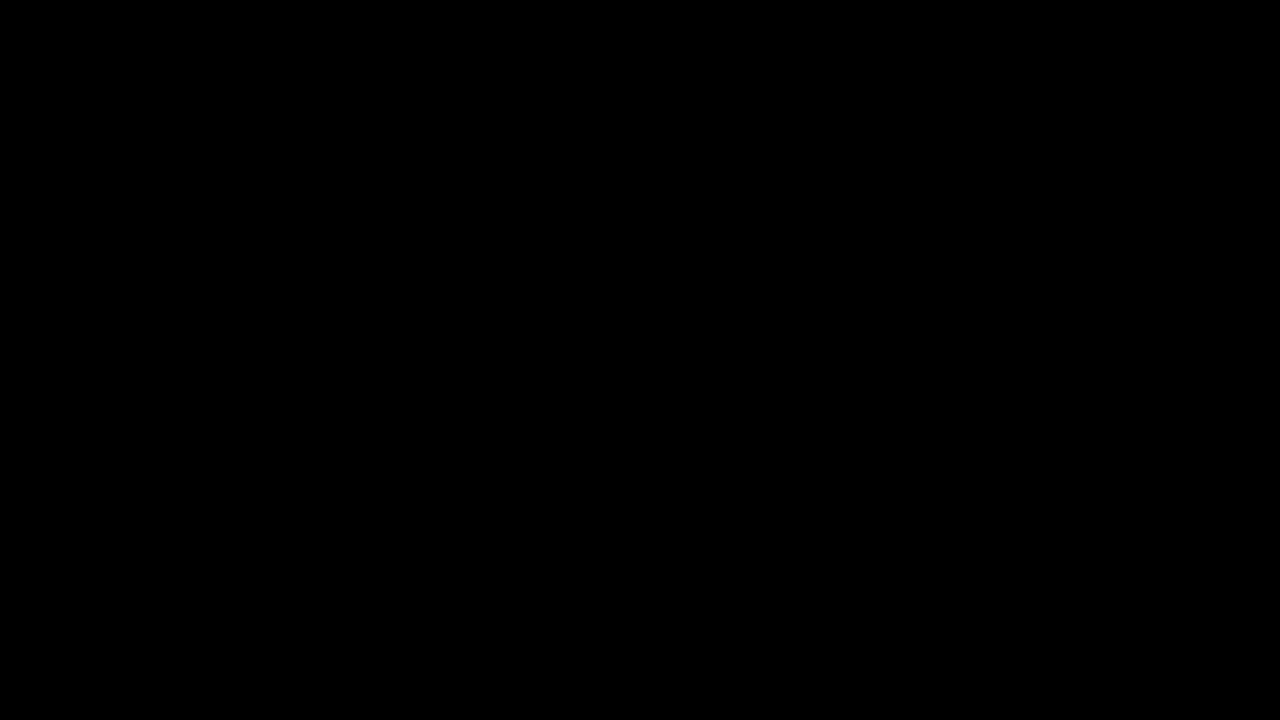

In [ ]:
%%manim -qm -v WARNING BiasVarianceDartboard


class BiasVarianceDartboard(Scene):
    """Dart-board analogy for bias vs. variance."""

    def construct(self):
        title = Text("Bias-Variance Tradeoff", font_size=30).to_edge(UP)
        self.play(Write(title))

        rng_m = np.random.default_rng(42)

        configs = [
            ("Low bias\nLow variance", 0, 0, 0.15, LEFT * 3.5),
            ("Low bias\nHigh variance", 0, 0, 0.6, LEFT * 0.5),
            ("High bias\nLow variance", 0.7, 0.5, 0.15, RIGHT * 2.5),
        ]

        for label_text, bx, by, spread, pos in configs:
            # Target circles
            for r in [1.0, 0.65, 0.3]:
                ring = Circle(radius=r, color=GREY, stroke_width=1).move_to(
                    pos + DOWN * 0.3
                )
                self.add(ring)
            bull = Dot(pos + DOWN * 0.3, color=C.SALMON, radius=0.06)
            self.add(bull)

            # Darts
            dots = VGroup()
            for _ in range(20):
                dx = rng_m.normal(bx, spread)
                dy = rng_m.normal(by, spread)
                dot = Dot(
                    pos + DOWN * 0.3 + RIGHT * dx + UP * dy,
                    color=C.PERIWINKLE,
                    radius=0.04,
                )
                dots.add(dot)

            label = Text(label_text, font_size=16).next_to(
                pos + DOWN * 0.3, DOWN, buff=1.2
            )

            self.play(FadeIn(dots), Write(label), run_time=0.8)

        self.wait(2)

The left board (low bias, low variance) is the ideal estimator — darts cluster tightly around the bullseye. The middle board (low bias, high variance) is unbiased but imprecise. The right board (high bias, low variance) is precise but systematically off-target. The MSE accounts for both.

In [ ]:
# MSE decomposition: numerical verification
# Compare two variance estimators: S² (unbiased, ddof=1) vs. σ̂² (biased, ddof=0)
true_var = 4.0
n = 5  # small n to make the difference visible
n_exp = 100_000

s2_unbiased = np.array([rng.normal(0, 2, n).var(ddof=1) for _ in range(n_exp)])
s2_biased = np.array([rng.normal(0, 2, n).var(ddof=0) for _ in range(n_exp)])

for name, est in [
    ("S² (ddof=1, unbiased)", s2_unbiased),
    ("σ̂² (ddof=0, biased)", s2_biased),
]:
    bias = est.mean() - true_var
    var = est.var()
    mse = np.mean((est - true_var) ** 2)
    print(f"{name}:")
    print(f"  Bias      = {bias:+.4f}")
    print(f"  Variance  = {var:.4f}")
    print(f"  MSE       = {mse:.4f}  (Bias² + Var = {bias**2 + var:.4f})")
    print()

S² (ddof=1, unbiased):
  Bias      = +0.0066
  Variance  = 8.0412
  MSE       = 8.0412  (Bias² + Var = 8.0412)

σ̂² (ddof=0, biased):
  Bias      = -0.8048
  Variance  = 5.1085
  MSE       = 5.7563  (Bias² + Var = 5.7563)



The biased estimator ($n$ in denominator) has slightly *lower* MSE than the unbiased one ($n-1$) for small $n$! Its bias is small, but its variance is lower because dividing by a larger number reduces spread. This is the tradeoff in action. As $n$ grows, the difference vanishes.

---

## 5. Consistency and Efficiency

### Consistency

An estimator is **consistent** if it converges to the true parameter as the sample size grows:

$$\hat{\theta}_n \xrightarrow{P} \theta \quad \text{as } n \to \infty$$

The sample mean $\bar{X}_n$ is consistent for $\mu$ — we proved this via the weak LLN (Module 01, notebook 06). A sufficient condition: $\text{MSE}(\hat{\theta}_n) \to 0$ as $n \to \infty$.

### Efficiency

Among all unbiased estimators, the one with the **smallest variance** is called **efficient** (or the UMVUE — uniformly minimum variance unbiased estimator). The **Cramér-Rao lower bound** gives a theoretical minimum:

$$\text{Var}(\hat{\theta}) \geq \frac{1}{n \cdot I(\theta)}$$

where $I(\theta) = -E\left[\frac{\partial^2}{\partial\theta^2}\log f(X;\theta)\right]$ is the **Fisher information**. An estimator that achieves this bound is efficient. MLE (notebook 03) is asymptotically efficient.

---

## 6. Summary: Evaluating Estimators

| Property         | Question                           | Formal criterion                          |
|------------------|------------------------------------|-------------------------------------------|
| **Unbiased**     | Does it hit the target on average? | $E[\hat{\theta}] = \theta$                |
| **Low variance** | How spread out is it?              | $\text{Var}(\hat{\theta})$ small          |
| **Consistent**   | Does it improve with more data?    | $\hat{\theta}_n \xrightarrow{P} \theta$   |
| **Efficient**    | Is it the best unbiased estimator? | Achieves Cramér-Rao bound                 |
| **Low MSE**      | Bias² + Variance combined          | $\text{MSE} = \text{Bias}^2 + \text{Var}$ |

---

## Exercises

**Exercise 1.1 (Bias of $\hat{\sigma}^2$).** Analytically show that $E\left[\frac{1}{n}\sum(X_i - \bar{X})^2\right] = \frac{n-1}{n}\sigma^2$. (*Hint:* expand $(X_i - \bar{X})^2 = (X_i - \mu) - (\bar{X} - \mu))^2$.)

**Exercise 1.2 (MSE simulation).** For $X \sim \text{Exponential}(\lambda = 2)$, compare two estimators of $\lambda$: (a) $\hat{\lambda}_1 = 1/\bar{X}$ (MLE), (b) $\hat{\lambda}_2 = (n-1)/(n\bar{X})$ (bias-corrected). Simulate 50,000 experiments with $n = 10$. Which has lower bias? Lower MSE?

**Exercise 1.3 (Consistency).** Simulate the sample mean for $X \sim \text{Poisson}(\lambda = 3)$ with $n = 5, 10, 50, 200, 1000$. For each $n$, compute the MSE of $\bar{X}$ as an estimator of $\lambda$. Plot MSE vs. $n$ and verify it goes to zero.

**Exercise 1.4 (Efficiency).** For $X \sim \mathcal{N}(\mu, \sigma^2)$ with known $\sigma^2$, the Cramér-Rao bound for estimating $\mu$ is $\sigma^2/n$. The sample mean achieves this: $\text{Var}(\bar{X}) = \sigma^2/n$. Show by simulation that the sample median has higher variance (it's unbiased but not efficient for Normal data).

**Exercise 1.5 (Challenge — James-Stein).** For $p \geq 3$ Normal means estimated simultaneously, the James-Stein estimator dominates the sample mean in total MSE. Read about it and explain why this is surprising.

---

## Key Takeaways

1. An **estimator** is a rule for computing an estimate from data; we evaluate it by bias, variance, and MSE.
2. $\bar{X}$ is unbiased for $\mu$; $S^2$ (with $n-1$) is unbiased for $\sigma^2$ — that's the formal proof of Bessel's correction.
3. $\text{MSE} = \text{Bias}^2 + \text{Variance}$ — sometimes a biased estimator wins on MSE.
4. **Consistency** means the estimator converges; **efficiency** means it has minimum variance among unbiased competitors.
5. These concepts set the stage for the specific estimation methods in the next notebooks: Method of Moments (notebook 02) and Maximum Likelihood (notebook 03).

**Next:** [02_method_of_moments.ipynb](02_method_of_moments.ipynb) — Deriving estimators by matching sample moments to theoretical ones.

In [7]:
cfg.save_gifs(clean=True)

  ✓ media/gifs/BiasVarianceDartboard@2026-03-19@16-26-55.gif
  ✓ media/gifs/BiasVarianceDartboard_ManimCE_v0.18.1.gif
  Cleaned up local temp render files (kept media/jupyter/).
